In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import os


In [89]:
df = pd.read_csv('students.csv')

FEATURES = [
    'Course', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
]

X, y = df[FEATURES], df['Target']


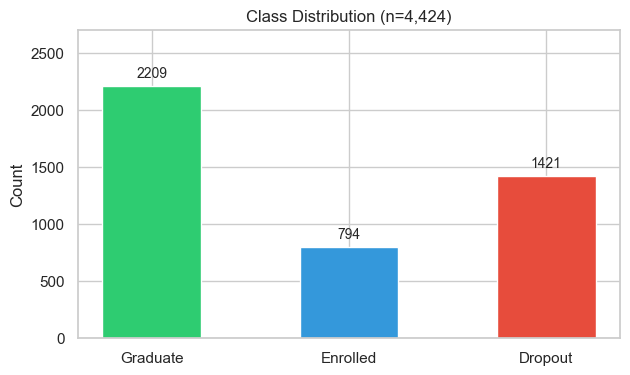

In [90]:
# 1. Class Distribution
order = ['Graduate', 'Enrolled', 'Dropout']
counts = y.value_counts()[order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, counts, color=colors, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, str(count),
            ha='center', va='bottom', fontsize=10)
ax.set(title='Class Distribution (n=4,424)', ylabel='Count', ylim=(0, 2700))
plt.show()


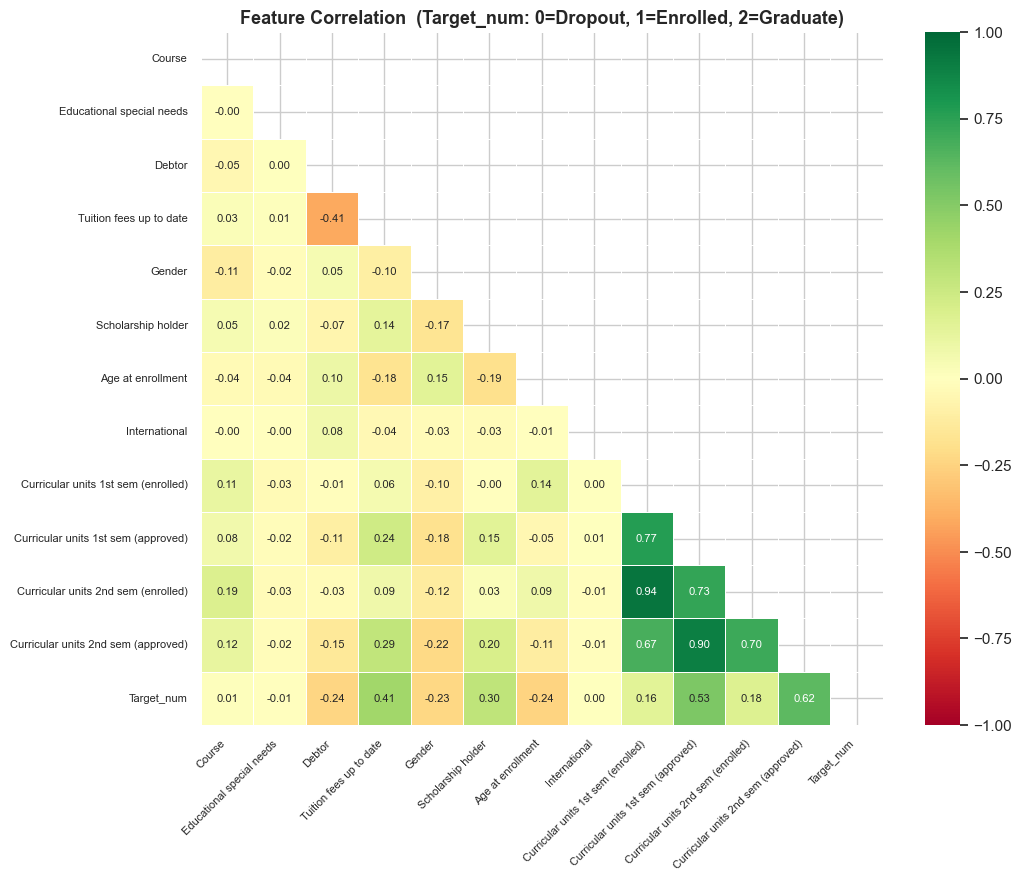

In [91]:
# 3. Correlation Heatmap
df_encoded = df.copy()
df_encoded['Target_num'] = df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
corr = df_encoded[FEATURES + ['Target_num']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation  (Target_num: 0=Dropout, 1=Enrolled, 2=Graduate)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.show()


C:\Users\cgwest\AppData\Local\Temp\ipykernel_33448\2834940844.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, order=order, palette=palette, ax=ax, width=0.5)
C:\Users\cgwest\AppData\Local\Temp\ipykernel_33448\2834940844.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, order=order, palette=palette, ax=ax, width=0.5)
C:\Users\cgwest\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


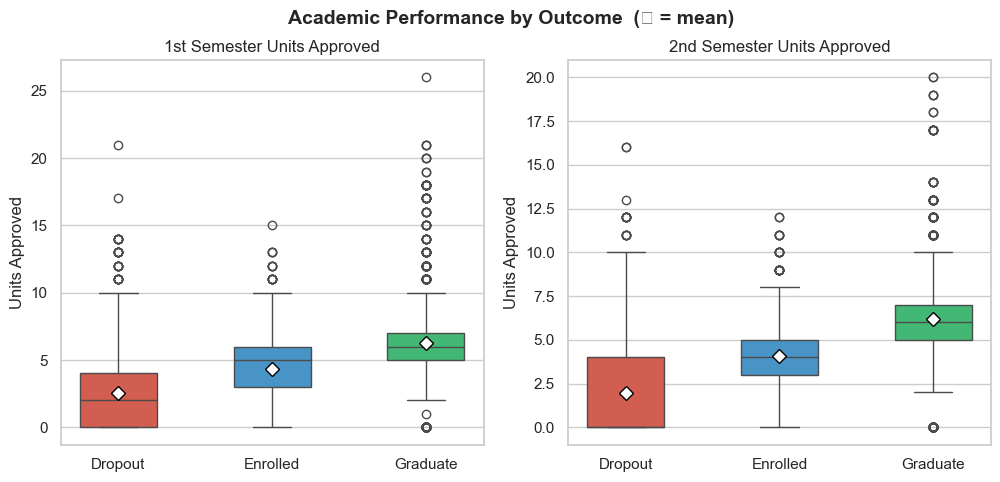

In [92]:
# 4. Academic Performance by Outcome
order = ['Dropout', 'Enrolled', 'Graduate']
cols   = ['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)']
titles = ['1st Semester Units Approved', '2nd Semester Units Approved']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, cols, titles):
    sns.boxplot(data=df, x='Target', y=col, order=order, palette=palette, ax=ax, width=0.5)
    means = df.groupby('Target')[col].mean()
    for i, g in enumerate(order):
        ax.plot(i, means[g], 'D', color='white', markersize=7, markeredgecolor='black', zorder=5)
    ax.set(title=title, xlabel='', ylabel='Units Approved')
plt.suptitle('Academic Performance by Outcome  (◆ = mean)', fontsize=14, fontweight='bold')
plt.show()


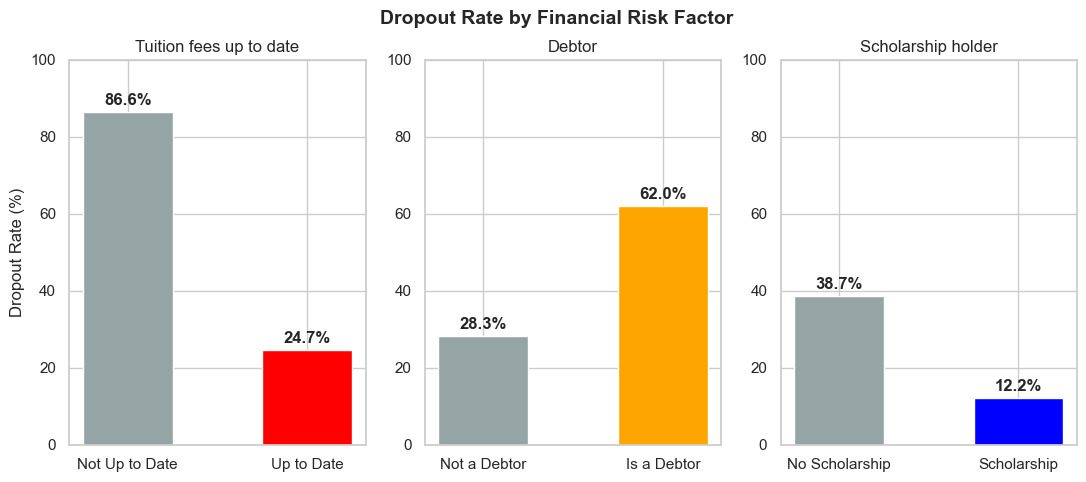

In [93]:
# 5. Financial Risk Factors
df['Is Dropout'] = (df['Target'] == 'Dropout').astype(int)

factors = [
    ('Tuition fees up to date', ['Not Up to Date', 'Up to Date'],  'red'),
    ('Debtor',                  ['Not a Debtor',   'Is a Debtor'], 'orange'),
    ('Scholarship holder',      ['No Scholarship', 'Scholarship'], 'blue'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, labels, color) in zip(axes, factors):
    rates = df.groupby(col)['Is Dropout'].mean() * 100
    bars = ax.bar(labels, rates.values, color=['#95a5a6', color], edgecolor='white', width=0.5)
    for bar, rate in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set(title=col, ylim=(0, 100))
    if ax is axes[0]:
        ax.set_ylabel('Dropout Rate (%)')
plt.suptitle('Dropout Rate by Financial Risk Factor', fontsize=14, fontweight='bold')
plt.show()


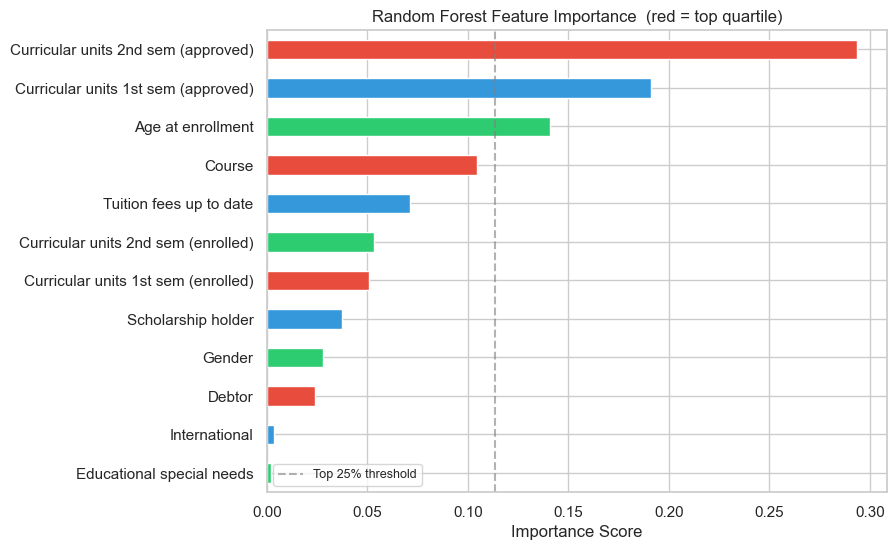

In [94]:
# 6. Feature Importance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                              min_samples_leaf=2, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(importances.quantile(0.75), color='gray', linestyle='--', alpha=0.6, label='Top 25% threshold')
ax.set(title='Random Forest Feature Importance  (red = top quartile)', xlabel='Importance Score')
ax.legend(fontsize=9)
plt.show()


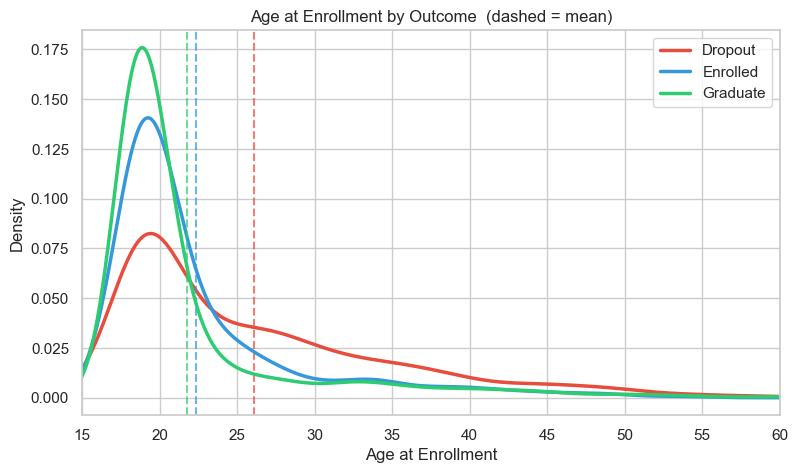

In [95]:
# 7. Age Distribution by Outcome
fig, ax = plt.subplots(figsize=(9, 5))
for outcome, color in palette.items():
    subset = df[df['Target'] == outcome]['Age at enrollment']
    subset.plot(kind='kde', ax=ax, label=outcome, color=color, linewidth=2.5)
    ax.axvline(subset.mean(), color=color, linestyle='--', alpha=0.7, linewidth=1.5)

ax.set(title='Age at Enrollment by Outcome  (dashed = mean)',
       xlabel='Age at Enrollment', ylabel='Density', xlim=(15, 60))
ax.legend(fontsize=11)
plt.show()


Outlier Report (IQR Method)
Age at enrollment
  Range: [10.0, 34.0]  |  Outliers: 441 (10.0%)

Curricular units 1st sem (enrolled)
  Range: [2.0, 10.0]  |  Outliers: 424 (9.6%)

Curricular units 1st sem (approved)
  Range: [-1.5, 10.5]  |  Outliers: 180 (4.1%)

Curricular units 2nd sem (enrolled)
  Range: [2.0, 10.0]  |  Outliers: 369 (8.3%)

Curricular units 2nd sem (approved)
  Range: [-4.0, 12.0]  |  Outliers: 44 (1.0%)



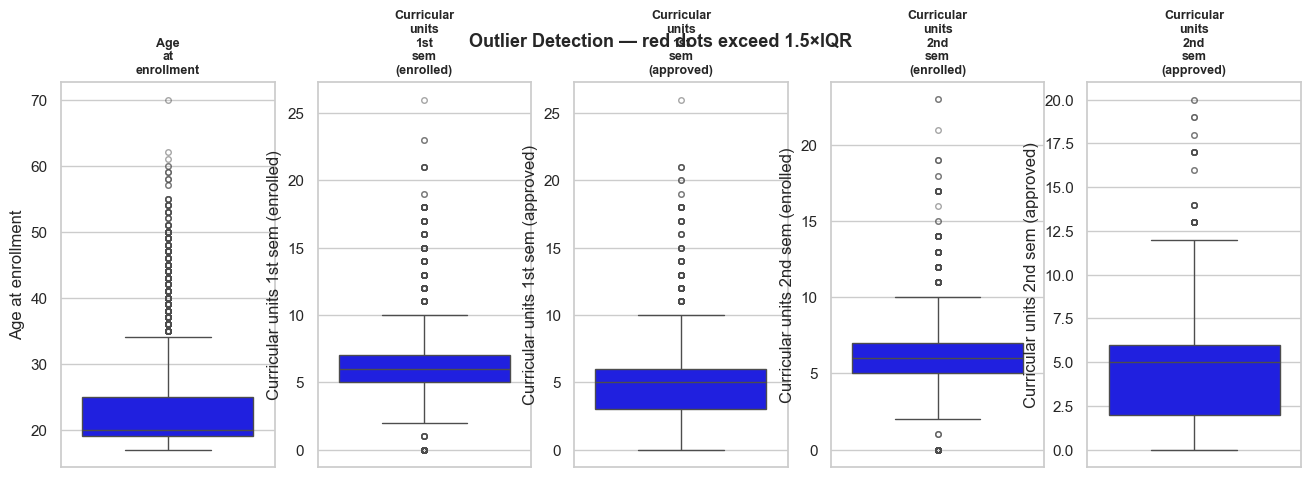

In [101]:
# 8. Outlier Detection (IQR)
numeric_features = [
    'Age at enrollment',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
]

print("Outlier Report (IQR Method)")
for col in numeric_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}\n  Range: [{lo:.1f}, {hi:.1f}]  |  Outliers: {n_out} ({n_out/len(df)*100:.1f}%)\n")

fig, axes = plt.subplots(1, len(numeric_features), figsize=(16, 5))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df, y=col, ax=ax, color='blue',
                flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
    ax.set_title(col.replace(' ', '\n'), fontsize=9, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Outlier Detection — red dots exceed 1.5×IQR', fontsize=13, fontweight='bold')
plt.show()


In [97]:
# 9. K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
df[['PCA1', 'PCA2']] = X_2d

print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")


Variance explained by 2 PCs: 43.3%


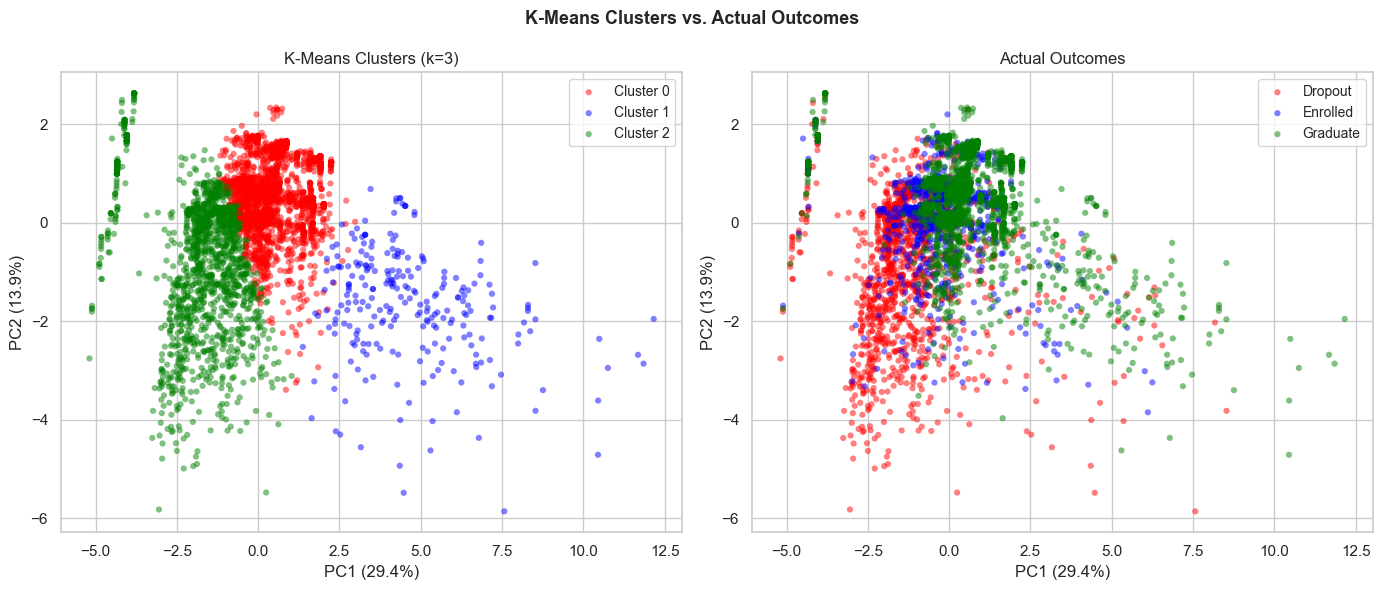

Cluster × Label Crosstab
Target   Dropout  Enrolled  Graduate  Total
Cluster                                    
0            316       511      1881   2708
1             49        30       170    249
2           1056       253       158   1467
Total       1421       794      2209   4424


In [102]:

cluster_colors = {0: 'red', 1: 'blue', 2: 'green'}
outcome_colors = {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for cid, color in cluster_colors.items():
    mask = df['Cluster'] == cid
    axes[0].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    c=color, label=f'Cluster {cid}', alpha=0.5, s=20, edgecolors='none')
axes[0].set(title='K-Means Clusters (k=3)',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=10)

for outcome, color in outcome_colors.items():
    mask = df['Target'] == outcome
    axes[1].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    c=color, label=outcome, alpha=0.5, s=20, edgecolors='none')
axes[1].set(title='Actual Outcomes',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(fontsize=10)

plt.suptitle('K-Means Clusters vs. Actual Outcomes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Cluster × Label Crosstab")
print(pd.crosstab(df['Cluster'], df['Target'], margins=True, margins_name='Total'))


In [99]:
# 10. Binary Model — Dropout vs. Graduate
from sklearn.metrics import classification_report, confusion_matrix, f1_score

df_binary = df[df['Target'] != 'Enrolled'].copy()
print(f"n={len(df_binary)}  |  Dropout: {(df_binary['Target']=='Dropout').sum()}  |  Graduate: {(df_binary['Target']=='Graduate').sum()}")

X_bin, y_bin = df_binary[FEATURES], df_binary['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

clf_binary = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                     min_samples_leaf=2, random_state=42, n_jobs=-1)
clf_binary.fit(X_train, y_train)
pred_binary = clf_binary.predict(X_test)

print("Binary Model (Dropout vs. Graduate)")
print(classification_report(y_test, pred_binary))


n=3630  |  Dropout: 1421  |  Graduate: 2209
Binary Model (Dropout vs. Graduate)
              precision    recall  f1-score   support

     Dropout       0.92      0.85      0.88       284
    Graduate       0.91      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



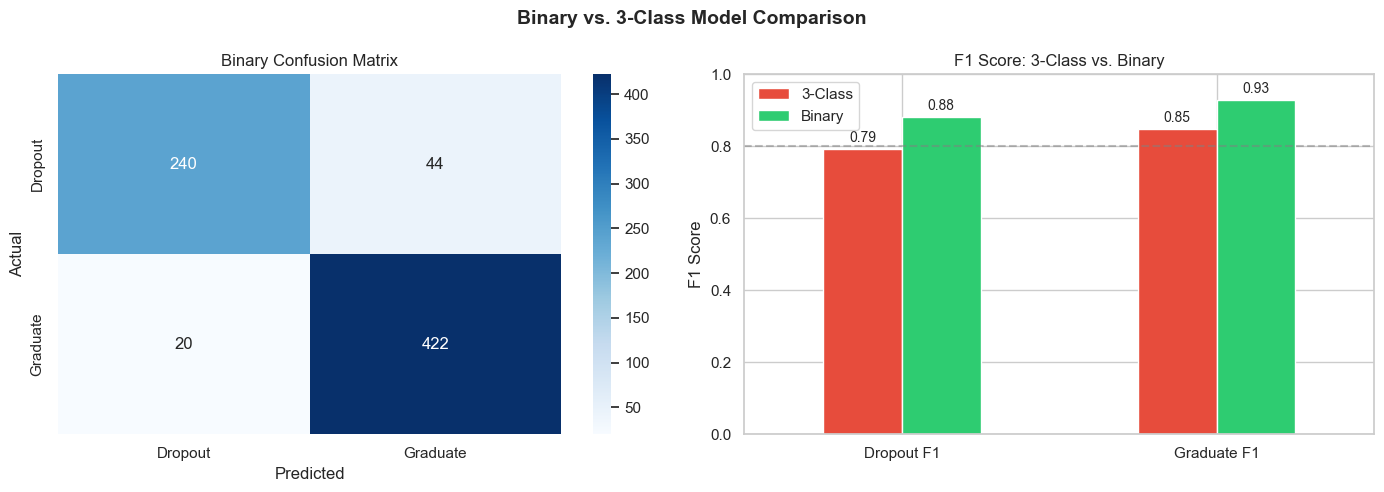

In [100]:

# 3-class model for F1 comparison
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
clf_3 = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                min_samples_leaf=2, random_state=42, n_jobs=-1)
clf_3.fit(X_train3, y_train3)
pred_3 = clf_3.predict(X_test3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, pred_binary, labels=['Dropout', 'Graduate'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Dropout', 'Graduate'], yticklabels=['Dropout', 'Graduate'])
axes[0].set(title='Binary Confusion Matrix', ylabel='Actual', xlabel='Predicted')

comparison = pd.DataFrame({
    '3-Class': f1_score(y_test3, pred_3, average=None, labels=['Dropout', 'Graduate']),
    'Binary':  f1_score(y_test, pred_binary, average=None, labels=['Dropout', 'Graduate']),
}, index=['Dropout F1', 'Graduate F1'])
comparison.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].axhline(0.8, color='gray', linestyle='--', alpha=0.5)
axes[1].set(title='F1 Score: 3-Class vs. Binary', ylabel='F1 Score', ylim=(0, 1))
axes[1].set_xticklabels(['Dropout F1', 'Graduate F1'], rotation=0)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.2f', padding=3, fontsize=10)

plt.suptitle('Binary vs. 3-Class Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

